In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

In [2]:
! which python

/home/veretenenko/miniconda3/envs/alchemistry/bin/python


In [3]:
from pymbar import MBAR
from alchemlyb.parsing.gmx import extract_u_nk, extract_dHdl
from alchemlyb.estimators import TI, BAR, MBAR

import warnings
warnings.filterwarnings('ignore')

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



# Шаг 1 — Сбор данных dhdl из всех окон


In [4]:
FOLDER='RUN0.MPA0'

N_WINDOWS = 24
T = 310.0  # K
kT = 8.31446e-3 * T  # это в кДж/моль
kcal = 1 / 4.184     # кДж/моль → ккал/моль, тоже "kT" но в ккал/моль

In [5]:
# if FOLDER.split('/')[0] == 'RSA_VBP': 
#     ylims = (110, 120)
# else:
ylims = (90, 110)

In [6]:
u_nk_list = []
dHdl_list = []

for i in range(N_WINDOWS):
    fname = f"{FOLDER}/window_{i:02d}/alch/alch.xvg"
    u_nk_list.append(extract_u_nk(fname, T=T))
    dHdl_list.append(extract_dHdl(fname, T=T))

u_nk_all = pd.concat(u_nk_list)

mbar = MBAR()
mbar.fit(u_nk_all)

dG_matrix = mbar.delta_f_  # в kT
ddG_matrix = mbar.d_delta_f_

dG_total = dG_matrix.iloc[0, -1] * kT
ddG_total = ddG_matrix.iloc[0, -1] * kT

print(f'ΔG_decoupling = {dG_total/4.184:.3f} ± {ddG_total/4.184:.3f} ккал/моль = {dG_total:.3f} ± {ddG_total:.3f} кДж/моль')


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************

I0000 00:00:1789480574.910403  339672 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


ΔG_decoupling = 95.640 ± 0.028 ккал/моль = 400.156 ± 0.118 кДж/моль


In [7]:
u_nk_all

,,,"(0.0, 0.0)","(0.1, 0.0)","(0.2, 0.0)","(0.3, 0.0)","(0.4, 0.0)","(0.5, 0.0)","(0.6, 0.0)","(0.7, 0.0)","(0.8, 0.0)","(0.9, 0.0)",...,"(1.0, 0.4)","(1.0, 0.5)","(1.0, 0.6)","(1.0, 0.7)","(1.0, 0.75)","(1.0, 0.8)","(1.0, 0.85)","(1.0, 0.9)","(1.0, 0.95)","(1.0, 1.0)"
time,coul-lambda,vdw-lambda,,,,,,,,,,,,,,,,,,,,,
0.0,0.0,0.0,7.441271e+01,1.049791e+02,1.355457e+02,1.661124e+02,1.966789e+02,2.272453e+02,2.578119e+02,2.883783e+02,3.189448e+02,3.495113e+02,...,397.319457,404.853713,412.952109,421.442204,425.794391,430.201535,434.653478,439.141554,443.658289,448.197255
0.2,0.0,0.0,7.444040e+01,1.041939e+02,1.339476e+02,1.637007e+02,1.934543e+02,2.232074e+02,2.529610e+02,2.827144e+02,3.124677e+02,3.422210e+02,...,390.642437,398.357951,406.558644,415.085511,419.435568,423.828784,428.256339,432.710742,437.185615,441.675475
0.4,0.0,0.0,7.441467e+01,1.072249e+02,1.400351e+02,1.728455e+02,2.056560e+02,2.384664e+02,2.712767e+02,3.040870e+02,3.368974e+02,3.697077e+02,...,418.862482,426.046117,433.758764,441.835321,445.972286,450.159475,454.387398,458.647914,462.934106,467.239973
0.6,0.0,0.0,7.440905e+01,1.052294e+02,1.360496e+02,1.668701e+02,1.976904e+02,2.285107e+02,2.593311e+02,2.901514e+02,3.209717e+02,3.517921e+02,...,400.015758,407.248425,414.977934,423.050525,427.180146,431.357286,435.573011,439.819630,444.090552,448.380081
0.8,0.0,0.0,7.442844e+01,1.041475e+02,1.338671e+02,1.635865e+02,1.933057e+02,2.230248e+02,2.527443e+02,2.824635e+02,3.121828e+02,3.419020e+02,...,390.270760,397.717888,405.638925,413.884825,418.095459,422.350404,426.641019,430.959949,435.300842,439.658251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999.2,1.0,1.0,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,4.193428e+12,...,580.834563,324.391477,195.067828,127.537861,107.321190,93.225828,83.821171,78.053801,75.135102,74.466260
4999.4,1.0,1.0,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,1.547707e+12,...,603.516466,335.612088,200.813308,130.444929,109.341324,94.584965,84.685608,78.547538,75.351793,74.477407
4999.6,1.0,1.0,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,1.753228e+12,...,567.784162,317.640694,191.352401,125.473114,105.807488,92.147628,83.094014,77.614861,74.937054,74.473053


In [8]:
TMAX=int(u_nk_all.index[-1][0])
TMAX

5000

# Шаг 2 - Зависимость dG от Tcut/Te

In [9]:
def filter_by_tcut(data_list, tcut_ps):
    filtered = []
    for d in data_list:
        time_idx = d.index.get_level_values('time')
        filtered.append(d[time_idx > tcut_ps])
    return filtered

def filter_by_te(data_list, te_ps):
    filtered = []
    for d in data_list:
        time_idx = d.index.get_level_values('time')
        filtered.append(d[time_idx <= te_ps])
    return filtered

def compute_dG_TI(dHdl_list):
    dHdl_all = pd.concat(dHdl_list)
    est = TI()
    est.fit(dHdl_all)
    dG = est.delta_f_.iloc[0, -1] * kT 
    ddG = est.d_delta_f_.iloc[0, -1] * kT
    return dG, ddG

def compute_dG_ukn(u_nk_list, estimator_cls):
    u_nk_all = pd.concat(u_nk_list)
    est = estimator_cls()
    est.fit(u_nk_all)
    
    dG = est.delta_f_.iloc[0, -1] * kT 
    
    if estimator_cls.__name__ == 'BAR':
        # BAR даёт ошибки только между соседними состояниями (диагональ k=1)
        # накапливаем через квадратичное суммирование
        errors = np.diag(est.d_delta_f_.values, k=1)
        ddG = np.sqrt(np.sum(errors**2))
    else:
        # MBAR даёт полную матрицу напрямую
        ddG = est.d_delta_f_.iloc[0, -1] * kT 
    
    return dG, ddG


## Tcut

In [10]:
TMAX//500 * 500

5000

In [11]:
TC=TMAX//2
dHdl_cut = filter_by_tcut(dHdl_list, TC)
u_nk_cut = filter_by_tcut(u_nk_list, TC)
    
dG, ddG = compute_dG_ukn(u_nk_cut, MBAR)
print(dG * kcal, ddG * kcal)

95.68946345440305 0.03975438386736721


In [12]:
TC

2500

In [13]:
tcuts = list(range(0, TMAX//500 * 500, 500))
results_tcut = {'TI': [], 'BAR': [], 'MBAR': []}
errors_tcut = {'TI': [], 'BAR': [], 'MBAR': []}

for tcut in tcuts:
    try: 
        dHdl_cut = filter_by_tcut(dHdl_list, tcut)
        u_nk_cut = filter_by_tcut(u_nk_list, tcut)

        dG, ddG = compute_dG_TI(dHdl_cut)
        results_tcut['TI'].append(dG * kcal); errors_tcut['TI'].append(ddG * kcal)

        for name, cls in [('BAR', BAR), ('MBAR', MBAR)]:
            dG, ddG = compute_dG_ukn(u_nk_cut, cls)
            results_tcut[name].append(dG * kcal)
            errors_tcut[name].append(ddG * kcal)
        print(f'tcut={tcut} пс готово')
    except: 
        pass

tcut=0 пс готово
tcut=500 пс готово
tcut=1000 пс готово
tcut=1500 пс готово
tcut=2000 пс готово
tcut=2500 пс готово
tcut=3000 пс готово
tcut=3500 пс готово
tcut=4000 пс готово
tcut=4500 пс готово


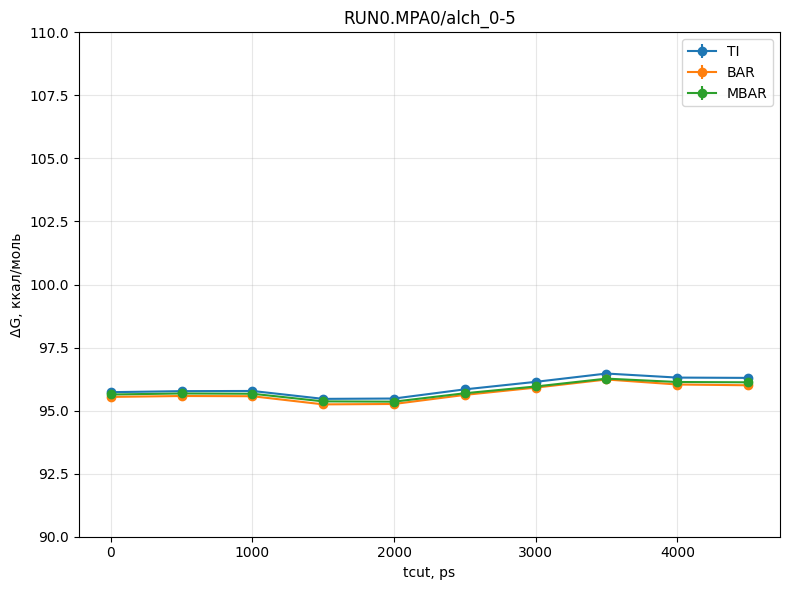

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'TI': 'tab:blue', 'BAR': 'tab:orange', 'MBAR': 'tab:green'}
for name in ['TI', 'BAR', 'MBAR']:
    tlen = len(results_tcut[name])
    ax.errorbar(tcuts[:tlen], results_tcut[name], yerr=errors_tcut[name],
                marker='o', label=name, color=colors[name])
ax.set_xlabel('tcut, ps')
ax.set_ylabel('ΔG, ккал/моль')
ax.set_ylim(ylims) #(110, 120)#(98, 104)#(100, 115))
ax.set_title(f'{FOLDER}/alch_0-5')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FOLDER}/dG_vs_tcut.png', dpi=150)
plt.show()

In [15]:
df_tcut = pd.DataFrame({
    'tcut': tcuts,
    'TI': results_tcut['TI'],
    'TI_Error': errors_tcut['TI'],
    'BAR': results_tcut['BAR'],
    'BAR_Error': errors_tcut['BAR'],
    'MBAR': results_tcut['MBAR'],
    'MBAR_Error': errors_tcut['MBAR'],
}).set_index('tcut')

display(df_tcut.round(2))


,TI,TI_Error,BAR,BAR_Error,MBAR,MBAR_Error
tcut,,,,,,
0,95.73,0.03,95.54,0.01,95.64,0.03
500,95.77,0.03,95.58,0.01,95.68,0.03
1000,95.78,0.03,95.57,0.01,95.67,0.03
1500,95.47,0.03,95.25,0.01,95.37,0.03
2000,95.48,0.04,95.26,0.01,95.36,0.04
2500,95.84,0.04,95.62,0.01,95.69,0.04
3000,96.14,0.04,95.91,0.01,95.96,0.04
3500,96.47,0.05,96.23,0.02,96.27,0.05
4000,96.31,0.06,96.04,0.02,96.13,0.06


## Te

In [16]:
Te_values = list(range(500, TMAX+5, 500))
#[500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
results_te = {'TI': [], 'BAR': [], 'MBAR': []}
errors_te = {'TI': [], 'BAR': [], 'MBAR': []}

for te in Te_values:
    tcut = te / 2
    dHdl_te = filter_by_tcut(filter_by_te(dHdl_list, te), tcut)
    u_nk_te = filter_by_tcut(filter_by_te(u_nk_list, te), tcut)

    dG, ddG = compute_dG_TI(dHdl_te)
    results_te['TI'].append(dG * kcal); errors_te['TI'].append(ddG * kcal)

    for name, cls in [('BAR', BAR), ('MBAR', MBAR)]:
        dG, ddG = compute_dG_ukn(u_nk_te, cls)
        results_te[name].append(dG * kcal)
        errors_te[name].append(ddG * kcal)
    print(f'Te={te} пс готово')

Te=500 пс готово
Te=1000 пс готово
Te=1500 пс готово
Te=2000 пс готово
Te=2500 пс готово
Te=3000 пс готово
Te=3500 пс готово
Te=4000 пс готово
Te=4500 пс готово
Te=5000 пс готово


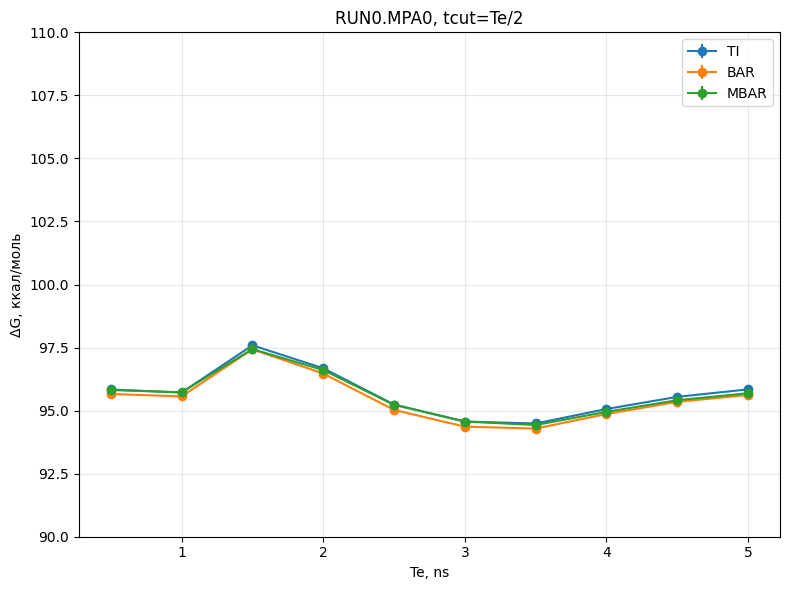

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in ['TI', 'BAR', 'MBAR']:
    ax.errorbar([te/1000 for te in Te_values], results_te[name], yerr=errors_te[name],
                marker='o', label=name, color=colors[name])
ax.set_xlabel('Te, ns')
ax.set_ylabel('ΔG, ккал/моль')
ax.set_ylim(ylims#(110, 120)#(98, 104
             )#(100, 115))
ax.set_title(f'{FOLDER}, tcut=Te/2')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FOLDER}/dG_vs_Te.png', dpi=150)
plt.show()

In [18]:
df_te = pd.DataFrame({
    'Te': Te_values, #range(1, len(Te_values) + 1),
    'TCUT': [te / 2 for te in Te_values],
    'TI': results_te['TI'],
    'TI_Error': errors_te['TI'],
    'BAR': results_te['BAR'],
    'BAR_Error': errors_te['BAR'],
    'MBAR': results_te['MBAR'],
    'MBAR_Error': errors_te['MBAR'],
}).set_index('Te')

display(df_te.round(2))


,TCUT,TI,TI_Error,BAR,BAR_Error,MBAR,MBAR_Error
Te,,,,,,,
500,250.0,95.84,0.12,95.66,0.04,95.82,0.13
1000,500.0,95.72,0.09,95.56,0.03,95.73,0.09
1500,750.0,97.59,0.07,97.43,0.02,97.44,0.07
2000,1000.0,96.68,0.06,96.47,0.02,96.61,0.06
2500,1250.0,95.24,0.06,95.03,0.02,95.23,0.06
3000,1500.0,94.57,0.05,94.36,0.02,94.57,0.05
3500,1750.0,94.49,0.05,94.29,0.01,94.43,0.05
4000,2000.0,95.06,0.04,94.87,0.01,94.95,0.04
4500,2250.0,95.55,0.04,95.35,0.01,95.41,0.04


# Шаг 3 — Проверка перекрытия (overlap matrix)

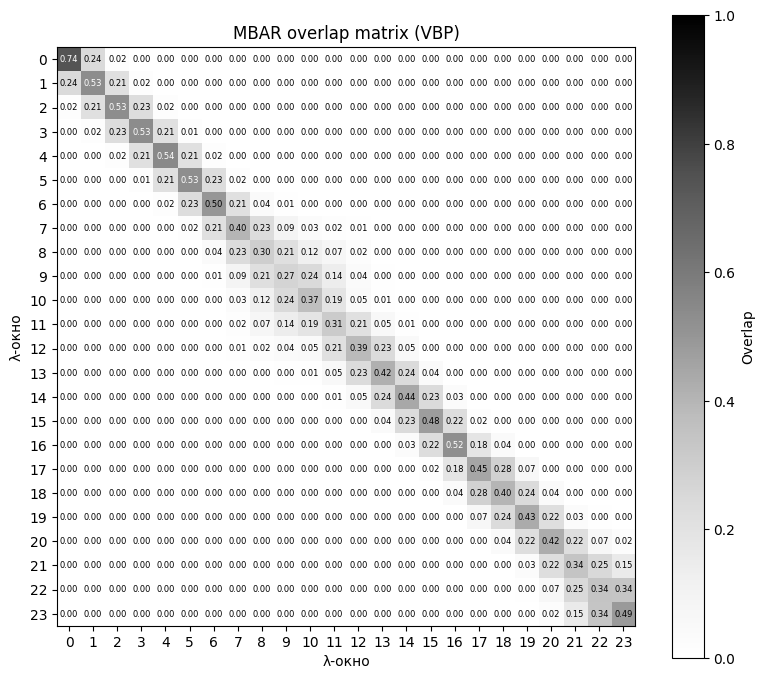

Минимальное перекрытие соседних окон: 0.181
(желательно > 0.03, идеально > 0.1)


In [19]:
overlap = mbar.overlap_matrix


fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(overlap, cmap='Greys', vmin=0, vmax=1)

# Подписываем значения внутри ячеек
for i in range(overlap.shape[0]):
    for j in range(overlap.shape[1]):
        val = overlap[i, j]
        if val > 0:  # Подписываем только ненулевые значения (больше 0.00)
            # Если ячейка темная (значение > 0.5), текст делаем белым, иначе черным
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=6)

# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(np.arange(overlap.shape[1]))
ax.set_yticks(np.arange(overlap.shape[0]))

ax.set_xlabel('λ-окно')
ax.set_ylabel('λ-окно')
ax.set_title('MBAR overlap matrix (VBP)')
plt.colorbar(im, label='Overlap')
plt.tight_layout()
plt.savefig(f'{FOLDER}/overlap_vbp.png', dpi=150)
plt.show()

# Минимальное перекрытие между соседними окнами — критично для качества
diag_overlap = np.diag(overlap, k=1)
print(f'Минимальное перекрытие соседних окон: {diag_overlap.min():.3f}')
print(f'(желательно > 0.03, идеально > 0.1)')


# Шаг 4 — Профиль ⟨dH/dλ⟩ по окнам (для визуальной оценки сходимости)


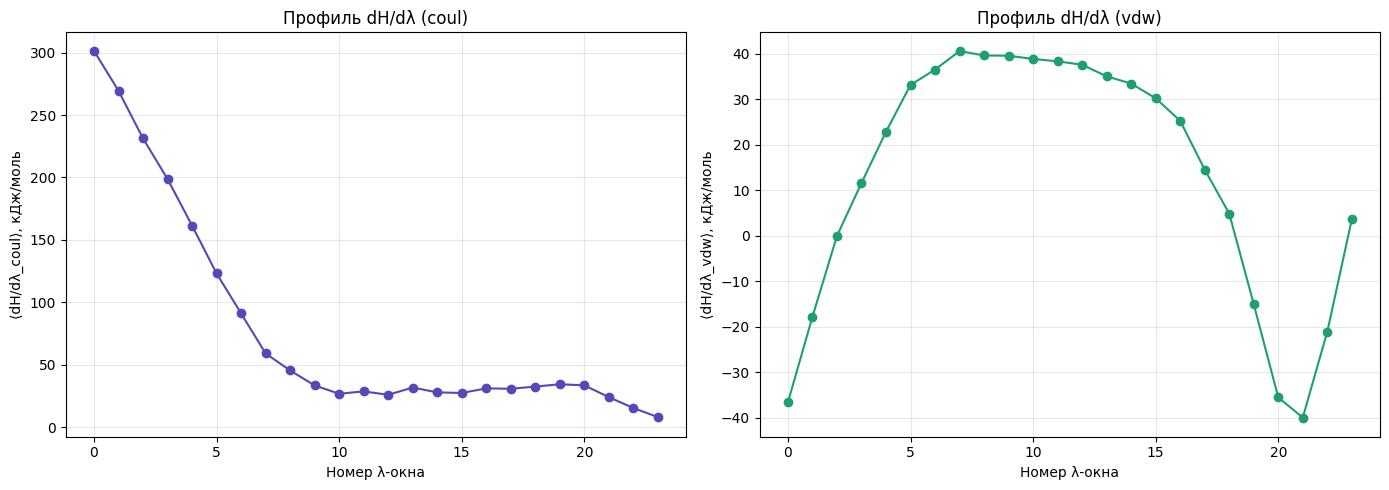

In [20]:
mean_dhdl_coul = [d['coul'].mean() for d in dHdl_list]
mean_dhdl_vdw = [d['vdw'].mean() for d in dHdl_list]

std_dhdl_coul = [d['coul'].std() / np.sqrt(len(d)) for d in dHdl_list]
std_dhdl_vdw = [d['vdw'].std() / np.sqrt(len(d)) for d in dHdl_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(range(len(dHdl_list)), mean_dhdl_coul, yerr=std_dhdl_coul, 
                  marker='o', color='#534AB7')
axes[0].set_xlabel('Номер λ-окна')
axes[0].set_ylabel('⟨dH/dλ_coul⟩, кДж/моль')
axes[0].set_title('Профиль dH/dλ (coul)')
axes[0].grid(alpha=0.3)

axes[1].errorbar(range(len(dHdl_list)), mean_dhdl_vdw, yerr=std_dhdl_vdw, 
                  marker='o', color='#1D9E75')
axes[1].set_xlabel('Номер λ-окна')
axes[1].set_ylabel('⟨dH/dλ_vdw⟩, кДж/моль')
axes[1].set_title('Профиль dH/dλ (vdw)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FOLDER}/dhdl_profile_vbp.png', dpi=150)
plt.show()


In [21]:
coul_lambda = [d.index[0][1] for d in dHdl_list]
vdw_lambda = [d.index[0][2] for d in dHdl_list]

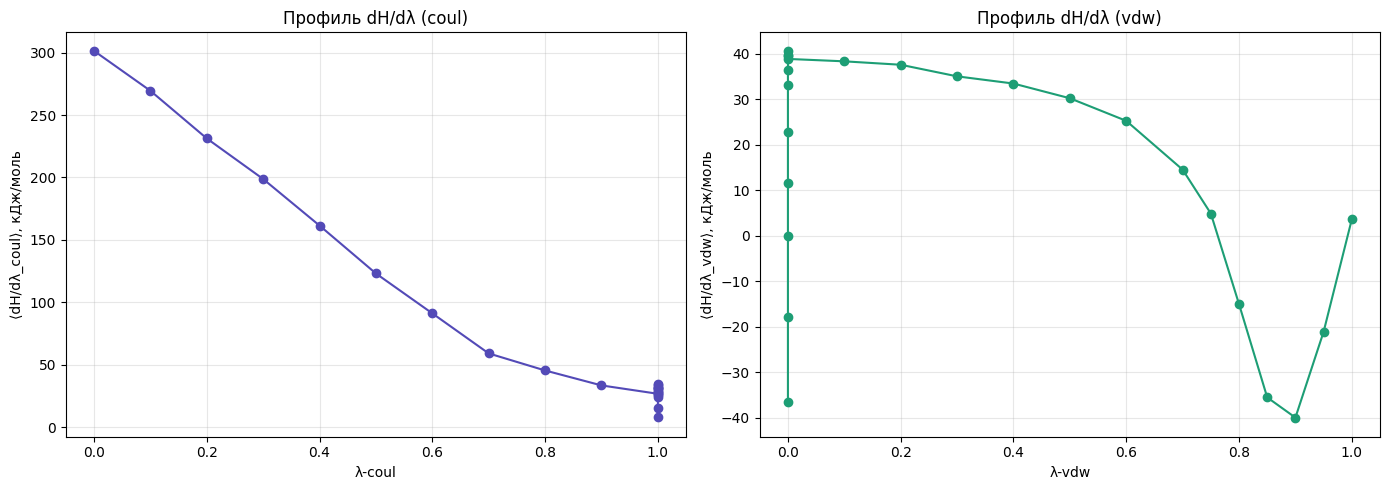

In [22]:
mean_dhdl_coul = [d['coul'].mean() for d in dHdl_list]
mean_dhdl_vdw = [d['vdw'].mean() for d in dHdl_list]

std_dhdl_coul = [d['coul'].std() / np.sqrt(len(d)) for d in dHdl_list]
std_dhdl_vdw = [d['vdw'].std() / np.sqrt(len(d)) for d in dHdl_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(coul_lambda, mean_dhdl_coul, yerr=std_dhdl_coul, 
                  marker='o', color='#534AB7')
axes[0].set_xlabel('λ-coul')
axes[0].set_ylabel('⟨dH/dλ_coul⟩, кДж/моль')
axes[0].set_title('Профиль dH/dλ (coul)')
axes[0].grid(alpha=0.3)

axes[1].errorbar(vdw_lambda, mean_dhdl_vdw, yerr=std_dhdl_vdw, 
                  marker='o', color='#1D9E75')
axes[1].set_xlabel('λ-vdw')
axes[1].set_ylabel('⟨dH/dλ_vdw⟩, кДж/моль')
axes[1].set_title('Профиль dH/dλ (vdw)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FOLDER}/dhdl_profile.png', dpi=150)
plt.show()


In [23]:
std_dhdl_coul

[0.1144796116272103,
 0.11507891204195579,
 0.11460050011665333,
 0.12023899857337335,
 0.11567342063290685,
 0.10501233015889001,
 0.10466426208505637,
 0.08779913474626794,
 0.07767736484185797,
 0.046799758775082655,
 0.06661382059869812,
 0.042417998364523576,
 0.06736906435485411,
 0.048162428474935924,
 0.049606628962394865,
 0.06461407818282291,
 0.04914167116546971,
 0.07187936833468342,
 0.13638087128722085,
 0.23613732475536547,
 0.41737325172548834,
 0.7296363473630796,
 0.9034366913671757,
 1.018108590703967]

# Шаг 5 — Сходимость по времени (forward/backward)


In [24]:
from alchemlyb.visualisation import plot_convergence
from alchemlyb.convergence import forward_backward_convergence

2026-09-15 17:02:55.149 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:68 - Start convergence analysis.
2026-09-15 17:02:55.150 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:69 - Check data availability.
2026-09-15 17:02:55.151 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:86 - Use MBAR estimator for convergence analysis.
2026-09-15 17:02:55.152 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:88 - Begin forward analysis
2026-09-15 17:02:55.152 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:92 - Forward analysis: 10.00%


2026-09-15 17:02:57.365 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:111 - 154.66 +/- 0.14 kT
2026-09-15 17:02:57.366 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:92 - Forward analysis: 20.00%
2026-09-15 17:03:01.644 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:111 - 155.04 +/- 0.10 kT
2026-09-15 17:03:01.645 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:92 - Forward analysis: 30.00%
2026-09-15 17:03:07.162 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:111 - 156.28 +/- 0.08 kT
2026-09-15 17:03:07.164 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:92 - Forward analysis: 40.00%
2026-09-15 17:03:14.246 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:111 - 155.93 +/- 0.07 kT
2026-09-15 17:03:14.247 | INFO     | alchemlyb.convergence.convergence:forward_backward_convergence:92 - Forwa

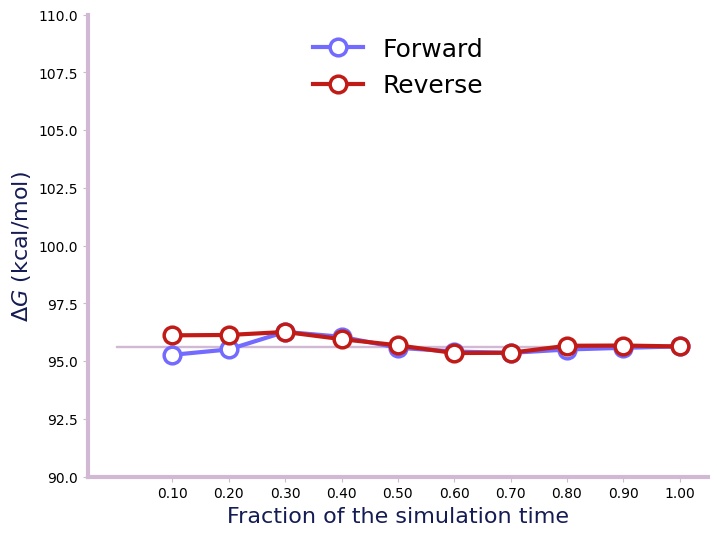

In [25]:
df_conv = forward_backward_convergence(u_nk_list, estimator='MBAR')

# explicit conversion units — важно указать T для конвертации из kT
df_conv.attrs['temperature'] = 310.0
df_conv.attrs['energy_unit'] = 'kT'

ax = plot_convergence(df_conv, units='kcal/mol')
plt.ylim(ylims)
plt.savefig(f'{FOLDER}/convergence_vbp.png', dpi=150)
plt.show()

# И явно вывести финальное значение для проверки:
# print(df_conv[['Forward', 'Forward_Error', 'Reverse', 'Reverse_Error']])


In [26]:
df_conv1 = df_conv.copy()
df_conv1[['Forward', 'Forward_Error', 'Backward', 'Backward_Error']] *= kT*kcal
display(df_conv1.round(2))

,Forward,Forward_Error,Backward,Backward_Error,data_fraction
0,95.28,0.09,96.12,0.09,0.1
1,95.51,0.06,96.14,0.06,0.2
2,96.27,0.05,96.27,0.05,0.3
3,96.06,0.04,95.96,0.04,0.4
4,95.58,0.04,95.69,0.04,0.5
5,95.42,0.04,95.35,0.04,0.6
6,95.36,0.03,95.37,0.03,0.7
7,95.51,0.03,95.67,0.03,0.8
8,95.58,0.03,95.68,0.03,0.9
9,95.64,0.03,95.64,0.03,1.0
